# VFA-1 — Feature Extractor Comparison

Trains three agents on a 10×10 `FogGridWorld` for **5 000 episodes each** and plots
their learning curves on a single chart.

| Agent | Colour | Parameters |
|-------|--------|------------|
| Tabular Q-Learning | blue | ~750k Q-entries (grows every episode) |
| Linear FA — Simple | red | 5 weights |
| Linear FA — Rich | green | 13 weights |

**Scientific question:** does a richer feature set improve performance
relative to the minimal 5-feature extractor, and by how much compared
to the tabular baseline?

In [1]:
import sys
from pathlib import Path

root = Path.cwd()
while not (root / 'src' / 'environment').exists() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.environment.grid_world import FogGridWorld
from src.agents.tabular_q import TabularQAgent
from src.agents.linear_fa import LinearFAAgent
from src.features.feature_extractor import SimpleFeatureExtractor, RichFeatureExtractor

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## 1. Train all three agents

All agents share the same environment object so they encounter identical
random map sequences.  Each episode resets with a new random layout.

Hyperparameters follow the VFA-1 spec:
- `alpha = 0.1` for Tabular (Q-entries are independent)
- `alpha = 0.01` for both FA agents (one theta update shifts every state's estimate)

In [2]:
N_TRAIN = 5000
GRID    = 10
SMOOTH  = 50

env = FogGridWorld(grid_size=GRID)

# ── Tabular Q ────────────────────────────────────────────────────────────────
agent_q = TabularQAgent(
    n_actions     = env.action_space.n,
    alpha         = 0.1,
    gamma         = 0.99,
    epsilon_start = 1.0,
    epsilon_end   = 0.05,
    epsilon_decay = 0.995,
)

q_rewards:     list[float] = []
q_table_sizes: list[int]   = []

for ep in range(1, N_TRAIN + 1):
    obs, _ = env.reset()
    ep_reward, done = 0.0, False
    while not done:
        action = agent_q.select_action(obs)
        next_obs, reward, terminated, truncated, _ = env.step(action)
        agent_q.update(obs, action, reward, next_obs, terminated)
        obs = next_obs
        ep_reward += reward
        done = terminated or truncated
    agent_q.decay_epsilon()
    q_rewards.append(ep_reward)
    q_table_sizes.append(agent_q.q_table_size)
    if ep % 1000 == 0:
        print(f'[Tabular]   ep {ep:>5}  avg(100) {np.mean(q_rewards[-100:]):+.3f}'
              f'  eps {agent_q.epsilon:.3f}  entries {agent_q.q_table_size:,}')

[Tabular]   ep  1000  avg(100) -1.696  eps 0.050  entries 173,499
[Tabular]   ep  2000  avg(100) -1.641  eps 0.050  entries 339,971


[Tabular]   ep  3000  avg(100) -1.485  eps 0.050  entries 487,818
[Tabular]   ep  4000  avg(100) -1.740  eps 0.050  entries 629,924
[Tabular]   ep  5000  avg(100) -1.610  eps 0.050  entries 764,856


In [3]:
# ── Linear FA — Simple (5 features) ──────────────────────────────────────────
agent_simple = LinearFAAgent(
    n_actions     = env.action_space.n,
    max_steps     = env.max_steps,
    alpha         = 0.01,
    gamma         = 0.99,
    epsilon_start = 1.0,
    epsilon_end   = 0.05,
    epsilon_decay = 0.995,
    # feature_extractor defaults to SimpleFeatureExtractor()
)

simple_rewards: list[float] = []

for ep in range(1, N_TRAIN + 1):
    obs, _ = env.reset()
    ep_reward, done = 0.0, False
    while not done:
        action = agent_simple.select_action(obs)
        next_obs, reward, terminated, truncated, _ = env.step(action)
        agent_simple.update(obs, action, reward, next_obs, terminated, truncated)
        obs = next_obs
        ep_reward += reward
        done = terminated or truncated
    agent_simple.decay_epsilon()
    simple_rewards.append(ep_reward)
    if ep % 1000 == 0:
        print(f'[Simple FA] ep {ep:>5}  avg(100) {np.mean(simple_rewards[-100:]):+.3f}'
              f'  eps {agent_simple.epsilon:.3f}  theta {np.round(agent_simple.theta, 3)}')

[Simple FA] ep  1000  avg(100) -0.958  eps 0.050  theta [-0.021  0.042 -0.604 -0.004 -0.295]
[Simple FA] ep  2000  avg(100) -0.828  eps 0.050  theta [-0.022  0.168 -0.555  0.023 -0.303]
[Simple FA] ep  3000  avg(100) -0.919  eps 0.050  theta [-0.02   0.067 -0.593  0.013 -0.285]


[Simple FA] ep  4000  avg(100) -0.848  eps 0.050  theta [-0.021  0.088 -0.59  -0.005 -0.281]


[Simple FA] ep  5000  avg(100) -0.998  eps 0.050  theta [-0.021  0.045 -0.627  0.002 -0.264]


In [4]:
# ── Linear FA — Rich (13 features) ───────────────────────────────────────────
agent_rich = LinearFAAgent(
    n_actions         = env.action_space.n,
    max_steps         = env.max_steps,
    alpha             = 0.01,
    gamma             = 0.99,
    epsilon_start     = 1.0,
    epsilon_end       = 0.05,
    epsilon_decay     = 0.995,
    feature_extractor = RichFeatureExtractor(),
)

rich_rewards: list[float] = []

for ep in range(1, N_TRAIN + 1):
    obs, _ = env.reset()
    ep_reward, done = 0.0, False
    while not done:
        action = agent_rich.select_action(obs)
        next_obs, reward, terminated, truncated, _ = env.step(action)
        agent_rich.update(obs, action, reward, next_obs, terminated, truncated)
        obs = next_obs
        ep_reward += reward
        done = terminated or truncated
    agent_rich.decay_epsilon()
    rich_rewards.append(ep_reward)
    if ep % 1000 == 0:
        print(f'[Rich FA]   ep {ep:>5}  avg(100) {np.mean(rich_rewards[-100:]):+.3f}'
              f'  eps {agent_rich.epsilon:.3f}')

[Rich FA]   ep  1000  avg(100) -0.997  eps 0.050


[Rich FA]   ep  2000  avg(100) -0.919  eps 0.050


[Rich FA]   ep  3000  avg(100) -0.933  eps 0.050


[Rich FA]   ep  4000  avg(100) -0.826  eps 0.050


[Rich FA]   ep  5000  avg(100) -1.009  eps 0.050


## 2. Learning-curve comparison

All three smoothed curves on one plot.  The bottom panel shows the
explosive Q-table growth versus the fixed parameter count of both FA agents.

**Interpretation:**
- The Q-table plateaus at a high negative reward because new random maps
  always produce unseen states — learned entries never transfer.
- Both FA curves stabilise at a significantly higher reward because
  `phi(s, a)` generalises across layouts.
- Whether Rich FA improves on Simple FA depends on whether the extra
  features (goal direction, wall density, trap/energy visibility) carry
  signal the 5-feature set misses.

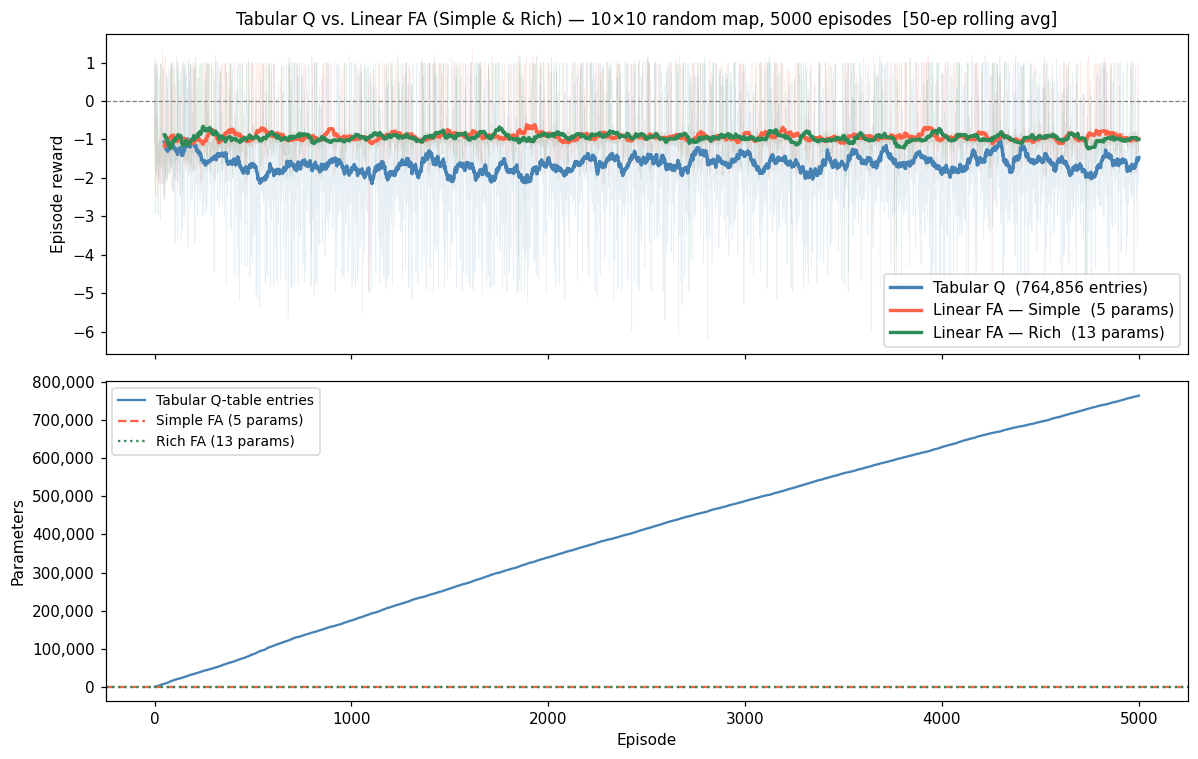

Tabular Q     last-100 avg: -1.6096  |  764,856 entries
Simple FA     last-100 avg: -0.9976  |  5 params
Rich FA       last-100 avg: -1.0087  |  13 params


In [5]:
episodes = np.arange(1, N_TRAIN + 1)
kernel   = np.ones(SMOOTH) / SMOOTH
x_smooth = episodes[SMOOTH - 1:]

q_smooth      = np.convolve(q_rewards,      kernel, mode='valid')
simple_smooth = np.convolve(simple_rewards, kernel, mode='valid')
rich_smooth   = np.convolve(rich_rewards,   kernel, mode='valid')

n_simple = agent_simple.feature_extractor.n_features
n_rich   = agent_rich.feature_extractor.n_features

fig, (ax_r, ax_p) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# ── Reward panel ──────────────────────────────────────────────────────────────
ax_r.plot(episodes, q_rewards,      alpha=0.12, color='steelblue', linewidth=0.5)
ax_r.plot(episodes, simple_rewards, alpha=0.12, color='tomato',    linewidth=0.5)
ax_r.plot(episodes, rich_rewards,   alpha=0.12, color='seagreen',  linewidth=0.5)

ax_r.plot(x_smooth, q_smooth,
          color='steelblue', linewidth=2.2,
          label=f'Tabular Q  ({agent_q.q_table_size:,} entries)')
ax_r.plot(x_smooth, simple_smooth,
          color='tomato', linewidth=2.2,
          label=f'Linear FA — Simple  ({n_simple} params)')
ax_r.plot(x_smooth, rich_smooth,
          color='seagreen', linewidth=2.2,
          label=f'Linear FA — Rich  ({n_rich} params)')

ax_r.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax_r.set_ylabel('Episode reward')
ax_r.legend(loc='lower right', fontsize=10)
ax_r.set_title(
    f'Tabular Q vs. Linear FA (Simple & Rich) — '
    f'{GRID}×{GRID} random map, {N_TRAIN} episodes  [{SMOOTH}-ep rolling avg]',
    fontsize=11,
)

# ── Parameter count panel ─────────────────────────────────────────────────────
ax_p.plot(episodes, q_table_sizes,
          color='steelblue', linewidth=1.5, label='Tabular Q-table entries')
ax_p.axhline(n_simple, color='tomato',   linewidth=1.5, linestyle='--',
             label=f'Simple FA ({n_simple} params)')
ax_p.axhline(n_rich,   color='seagreen', linewidth=1.5, linestyle=':',
             label=f'Rich FA ({n_rich} params)')
ax_p.set_ylabel('Parameters')
ax_p.set_xlabel('Episode')
ax_p.legend(fontsize=9)
ax_p.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

plt.tight_layout()
plt.show()

print(f'Tabular Q     last-100 avg: {np.mean(q_rewards[-100:]):+.4f}  |  {agent_q.q_table_size:,} entries')
print(f'Simple FA     last-100 avg: {np.mean(simple_rewards[-100:]):+.4f}  |  {n_simple} params')
print(f'Rich FA       last-100 avg: {np.mean(rich_rewards[-100:]):+.4f}  |  {n_rich} params')

## 3. Learned weight comparison

Simple and Rich FA both produce interpretable weight vectors.

Features 0–4 are shared; the Rich extractor adds 8 more:

| Index | Feature             | Range    | Expected sign |
|-------|---------------------|----------|---------------|
| 0     | `wall_ahead`        | [0, 1]   | − |
| 1     | `goal_visible`      | [0, 1]   | + |
| 2     | `energy_level`      | [0, 1]   | − (more steps → more step costs) |
| 3     | `energy_pickup_vis` | [0, 1]   | + |
| 4     | `step_progress`     | [0, 1]   | − |
| 5     | `delta_row_goal`    | [−1, 1]  | context-dependent |
| 6     | `delta_col_goal`    | [−1, 1]  | context-dependent |
| 7     | `walls_norm`        | [0, 1]   | context-dependent |
| 8     | `free_cells_norm`   | [0, 1]   | context-dependent |
| 9     | `trap_visible`      | [0, 1]   | − |
| 10    | `delta_row_energy`  | [−1, 1]  | context-dependent |
| 11    | `delta_col_energy`  | [−1, 1]  | context-dependent |
| 12    | `rho_norm`          | [0.5, 1] | context-dependent |

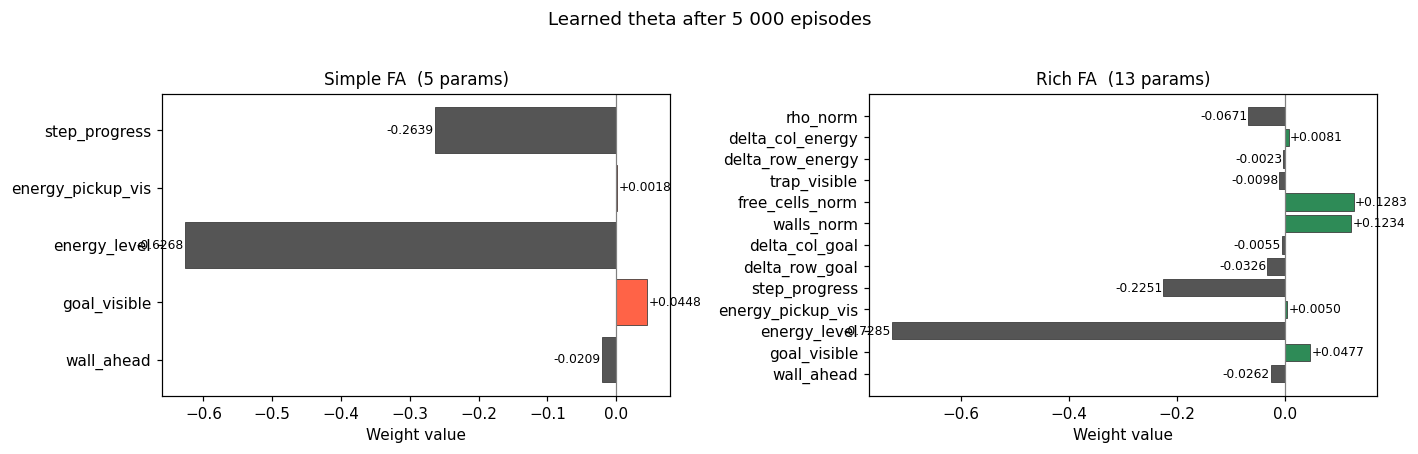

In [6]:
simple_names = [
    'wall_ahead', 'goal_visible', 'energy_level',
    'energy_pickup_vis', 'step_progress',
]
rich_names = simple_names + [
    'delta_row_goal', 'delta_col_goal',
    'walls_norm', 'free_cells_norm',
    'trap_visible',
    'delta_row_energy', 'delta_col_energy',
    'rho_norm',
]

fig, (ax_s, ax_r) = plt.subplots(1, 2, figsize=(13, 4))

for ax, theta, names, title, color in [
    (ax_s, agent_simple.weights, simple_names, f'Simple FA  (5 params)', 'tomato'),
    (ax_r, agent_rich.weights,   rich_names,   f'Rich FA  (13 params)',  'seagreen'),
]:
    colors = [color if w >= 0 else '#555555' for w in theta]
    bars = ax.barh(names, theta, color=colors, edgecolor='#333', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.8)
    for bar, val in zip(bars, theta):
        ax.text(
            val + (0.002 if val >= 0 else -0.002),
            bar.get_y() + bar.get_height() / 2,
            f'{val:+.4f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=8,
        )
    ax.set_xlabel('Weight value')
    ax.set_title(title, fontsize=11)

plt.suptitle('Learned theta after 5 000 episodes', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()